### Imports and Setup

In [1]:
import os

import torch
import numpy as np
import h5py
import matplotlib.pyplot as plt

from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassify
from whale_gunshot_localization.utils.experimental import Localizer, ClipAnalyzer, l2_standardize
from whale_gunshot_localization import config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")

Using the GPU!


### Load Model

In [2]:
model = TCNRangeAndClassify(input_size=232, 
                                     num_channels=7*[368],
                                     kernel_size=6,
                                     dropout=0.05).to(device)

# load model weights
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'] + '/range_classify', 'weights_best.pt'),
                        map_location=device)['model_state_dict']
model.load_state_dict(state_dict)

<All keys matched successfully>

### Setup Clip Analyzer + Localizer + Data

In [3]:
# set parameters
data_params = {'mu_list' : np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True),
               'std_list' : np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True),
               'fs' : config['signal']['fs'],
               'T' : config['signal']['T'],}

# instantiate clip analyzer object
CA = ClipAnalyzer(model, data_params, preprocessor=l2_standardize, device=device)

# instantiate localizer
l = Localizer(k=4, consistency_thresh=1000, method_thresh=0.95, prune=False)

# load data
with h5py.File(config['dataset']['exp_data_directory'] + "/" + "sandbox_data2.h5", "r") as f:
    data = f['data'][:]
if len(data.shape) == 2:
    data = data[np.newaxis,:,:]

### Analyze Data

Helper Functions

In [5]:
def plot_localization(locs_est, buffer=6000): 

    # load constants
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']

    plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], '^', markersize=12, label='sensor', markeredgewidth=2)
    plt.plot(locs_est[:,1], locs_est[:,0], 'x', label='estimate', markeredgewidth=2)
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.xlim([min_x-buffer, max_x+buffer])
    plt.ylim([min_y-buffer, max_y+buffer])
    plt.gca().invert_yaxis()
    plt.legend()
    plt.show()
    
def viz_associated_data(assocs, spects, timestamps):
    
    # flatten spectrograms
    flat_spects = np.concatenate([spect for spect in spects])
    flat_timestamps = np.concatenate([ts for ts in timestamps])
    
    for i, assoc in enumerate(assocs):
        
        # get spectrograms associated with association group i
        assoc = list(assoc)
        spect_group = flat_spects[assoc]
        ts_group = flat_timestamps[assoc]
        print(assoc)
        fig, axs = plt.subplots(1, len(spect_group), figsize=(10, 15))
        fig.suptitle(f"Association {i+1}", y=0.56)
        for j, (spect, ts) in enumerate(zip(spect_group, ts_group)):
            axs[j].axis('off')
            axs[j].imshow(spect)
            axs[j].set_title(f"{ts}")
        plt.tight_layout()
        plt.show()

Scan audio data and properly format measurements

In [6]:
# select row
row = 0

# scan data
res = CA.process_clips(data[row,...])

# format measurements and timestamps
spects, measurements, timestamps = [], [], []
for sensor in res:
    measurements.append(sensor[1])
    timestamps.append(sensor[2])
    spects.append(sensor[0])

In [7]:
measurements

[array([6955.712, 6622.495], dtype=float32),
 array([5388.6406, 5172.038 ], dtype=float32),
 array([4545.0127, 2570.8513], dtype=float32),
 array([5105.8247, 3602.2166], dtype=float32),
 array([7493.9106, 7449.5215], dtype=float32)]

Associate and localize

In [15]:
# create hypergraph
%time
success = l.set_measurements(measurements, adaptive=True)

if success:
    print("success!")
    # associate and localize
    assoc, locs_est = l.associate_and_localize(method='partition')
else:
    print("fail")

CPU times: user 7 µs, sys: 5 µs, total: 12 µs
Wall time: 24.3 µs
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
success!


[9, 3, 4, 6]


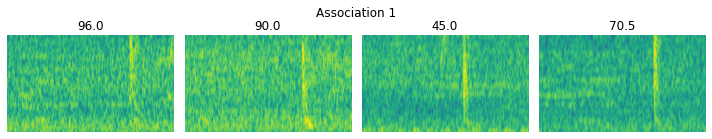

In [17]:
viz_associated_data(assoc, spects, timestamps)

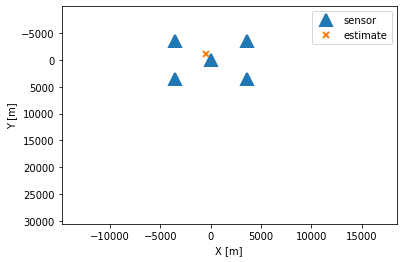

In [18]:
plot_localization(locs_est)